In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.chdir("/data/projects/liquid_biopsy/Projects/cfDNA/cfDNA/")


In [16]:
results_folder = "data/model_results/"
rbf_mapq0 = pd.read_csv(results_folder + "svm_rbf_cv1_cv_results.csv")
rbf_mapq15 = pd.read_csv(results_folder + "svm_rbf_cv1_mapq15_cv_results.csv")
rbf_mapq30 = pd.read_csv(results_folder + "svm_rbf_cv1_mapq30_cv_results.csv")
rbf_mapq45 = pd.read_csv(results_folder + "svm_rbf_cv1_mapq45_cv_results.csv")
zhou_scores = pd.DataFrame({
    'length': 0.8741, 'edm': 0.9736, 'fsd': 0.9271,
    'coverage': 0.9638, 'ends': 0.9639, 'ocf': 0.9467,
    'ifs': 0.9653, 'wps': 0.9658, 'pfe': 0.9579, 'fsr': 0.9441
}, index=[0]).T.rename(columns={0: 'auc'})
zhou_scores.index.name = 'feature'


In [17]:
features = pd.DataFrame(['length', 'fsd', 'fsr', 'pfe', 'coverage', 'ends', 'ocf', 'ifs', 'wps', 'edm', 'iedm', 'eedm', 'eoedm', 'cposedm'], columns=['feature'])

# merge into a single df, matching on feature name
auc_df = features.copy()
auc_df = auc_df.merge(rbf_mapq0[['feature', 'auc']].rename(columns={'auc': 'mapq0'}), on='feature', how='left')
auc_df = auc_df.merge(rbf_mapq15[['feature', 'auc']].rename(columns={'auc': 'mapq15'}), on='feature', how='left')
auc_df = auc_df.merge(rbf_mapq30[['feature', 'auc']].rename(columns={'auc': 'mapq30'}), on='feature', how='left')
auc_df = auc_df.merge(rbf_mapq45[['feature', 'auc']].rename(columns={'auc': 'mapq45'}), on='feature', how='left')
auc_df = auc_df.merge(zhou_scores.reset_index().rename(columns={'auc': 'zhou'}), on='feature', how='left')

plt.figure(figsize=(10, 6))
auc_df


,feature,mapq0,mapq15,mapq30,mapq45,zhou
0,length,0.838868,0.831768,0.827131,0.818276,0.8741
1,fsd,0.919653,0.882457,0.881885,0.878259,0.9271
2,fsr,NaN,NaN,NaN,NaN,0.9441
3,pfe,0.861493,0.867858,0.866388,0.864060,0.9579
4,coverage,0.776528,0.759676,0.773455,0.763350,0.9638
5,ends,0.798695,0.796805,0.785832,0.792673,0.9639
6,ocf,0.836921,0.830404,0.819382,0.813428,0.9467
7,ifs,0.813485,0.803943,0.810355,0.805689,0.9653
8,wps,0.775373,0.779324,0.777205,0.775955,0.9658
9,edm,0.962556,0.967928,0.968892,0.966468,0.9736


<Figure size 1000x600 with 0 Axes>

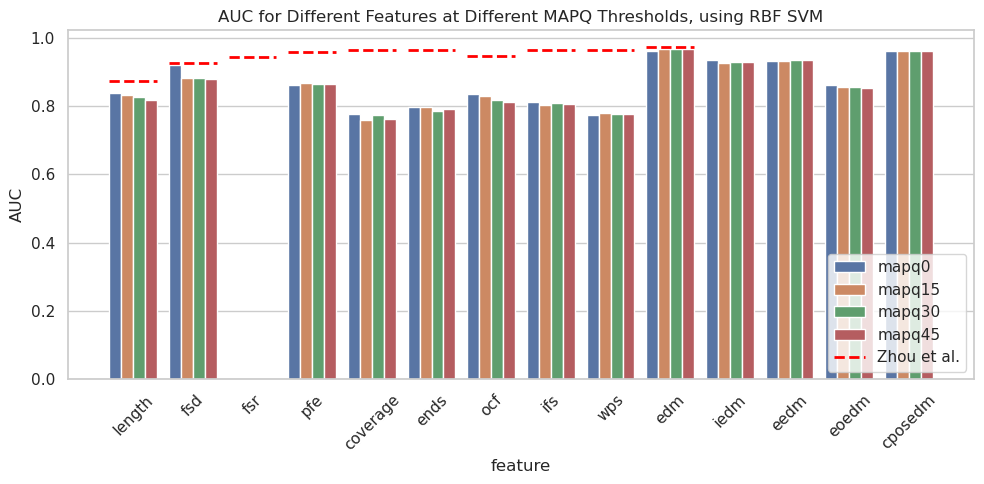

In [18]:
# bar plot of AUC distributions for different MAPQ thresholds
plt.figure(figsize=(10, 5))
# set theme to whitegrid
sns.set_theme(style="whitegrid")
auc_df_melted = auc_df.melt(id_vars='feature', value_vars=['mapq0', 'mapq15', 'mapq30', 'mapq45'], var_name='mapq', value_name='AUC')
ax = sns.barplot(data=auc_df_melted, x='feature', y='AUC', hue='mapq')
bar_width = 0.8
for i, zhou_val in enumerate(auc_df['zhou']):
    ax.hlines(
        zhou_val,
        i - bar_width / 2,
        i + bar_width / 2,
        colors='red',
        linewidth=2,
        linestyles='--',
        label='Zhou et al.' if i == 0 else ''
    )
plt.xticks(rotation=45)
# plt.ylim(0, 1.0)
plt.title('AUC for Different Features at Different MAPQ Thresholds, using RBF SVM')
plt.legend(loc='lower right')
plt.tight_layout()  
plt.savefig("scripts/analysis/01_mapq.png")

In [19]:
linear_mapq30 = pd.read_csv(results_folder + "svm_linear_cv1_mapq30_cv_results.csv")
rbf_mapq30 = pd.read_csv(results_folder + "svm_rbf_cv1_mapq30_cv_results.csv")
features = pd.DataFrame(['length', 'fsd', 'fsr', 'pfe', 'coverage', 'ends', 'ocf', 'ifs', 'wps', 'edm', 'iedm', 'eedm', 'eoedm', 'cposedm'], columns=['feature'])

auc_df = features.copy()
auc_df = auc_df.merge(rbf_mapq30[['feature', 'auc']].rename(columns={'auc': 'rbf'}), on='feature', how='left')
auc_df = auc_df.merge(linear_mapq30[['feature', 'auc']].rename(columns={'auc': 'linear'}), on='feature', how='left')
auc_df = auc_df.merge(zhou_scores.reset_index().rename(columns={'auc': 'zhou'}), on='feature', how='left')

# auc_df

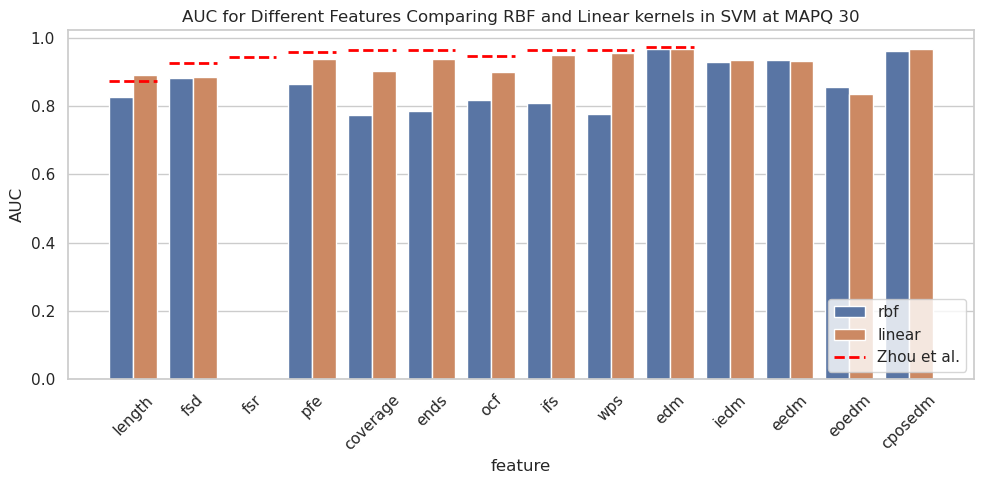

In [20]:
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")
auc_df_melted = auc_df.melt(id_vars='feature', value_vars=['rbf', 'linear'], var_name='Model', value_name='AUC')
ax = sns.barplot(data=auc_df_melted, x='feature', y='AUC', hue='Model')
bar_width = 0.8
for i, zhou_val in enumerate(auc_df['zhou']):
    ax.hlines(
        zhou_val,
        i - bar_width / 2,
        i + bar_width / 2,
        colors='red',
        linewidth=2,
        linestyles='--',
        label='Zhou et al.' if i == 0 else ''
    )
plt.xticks(rotation=45)
# plt.ylim(0.5, 1.0)
plt.title('AUC for Different Features Comparing RBF and Linear kernels in SVM at MAPQ 30')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("scripts/analysis/02_kernel.png")

## PCA

In [21]:
linear_no_pca_mapq30 = pd.read_csv(results_folder + "svm_linear_cv1_mapq30_cv_results.csv")
linear_pca50_mapq30 = pd.read_csv(results_folder + "svm_linear_pca50.0_cv1_mapq30_cv_results.csv")
linear_pca100_mapq30 = pd.read_csv(results_folder + "svm_linear_pca100.0_cv1_mapq30_cv_results.csv")
linear_pca150_mapq30 = pd.read_csv(results_folder + "svm_linear_pca150.0_cv1_mapq30_cv_results.csv")
linear_pca200_mapq30 = pd.read_csv(results_folder + "svm_linear_pca200.0_cv1_mapq30_cv_results.csv")
features = pd.DataFrame(['length', 'fsd', 'fsr', 'pfe', 'coverage', 'ends', 'ocf', 'ifs', 'wps', 'edm', 'iedm', 'eedm', 'eoedm', 'cposedm'], columns=['feature'])

auc_df = features.copy()
auc_df = auc_df.merge(linear_pca50_mapq30[['feature', 'auc']].rename(columns={'auc': 'pca50'}), on='feature', how='left')
auc_df = auc_df.merge(linear_pca100_mapq30[['feature', 'auc']].rename(columns={'auc': 'pca100'}), on='feature', how='left')
auc_df = auc_df.merge(linear_pca150_mapq30[['feature', 'auc']].rename(columns={'auc': 'pca150'}), on='feature', how='left')
auc_df = auc_df.merge(linear_pca200_mapq30[['feature', 'auc']].rename(columns={'auc': 'pca200'}), on='feature', how='left')
auc_df = auc_df.merge(linear_no_pca_mapq30[['feature', 'auc']].rename(columns={'auc': 'no_pca'}), on='feature', how='left')
auc_df = auc_df.merge(zhou_scores.reset_index().rename(columns={'auc': 'zhou'}), on='feature', how='left')
auc_df

,feature,pca50,pca100,pca150,pca200,no_pca,zhou
0,length,0.873907,0.902554,0.899786,0.890187,0.891093,0.8741
1,fsd,0.876503,0.885368,0.870739,0.867075,0.886618,0.9271
2,fsr,0.412229,NaN,0.743254,NaN,NaN,0.9441
3,pfe,0.914367,0.930904,0.950666,0.931104,0.936811,0.9579
4,coverage,0.323257,0.627810,0.947565,0.945017,0.903164,0.9638
5,ends,0.227127,0.801977,0.946467,0.951115,0.937650,0.9639
6,ocf,0.382801,0.432459,0.902763,0.934091,0.900884,0.9467
7,ifs,0.291462,0.836883,0.952632,0.955676,0.950971,0.9653
8,wps,0.270449,0.638479,0.942259,0.949177,0.955895,0.9658
9,edm,0.950323,0.953529,0.958348,0.961487,0.967442,0.9736


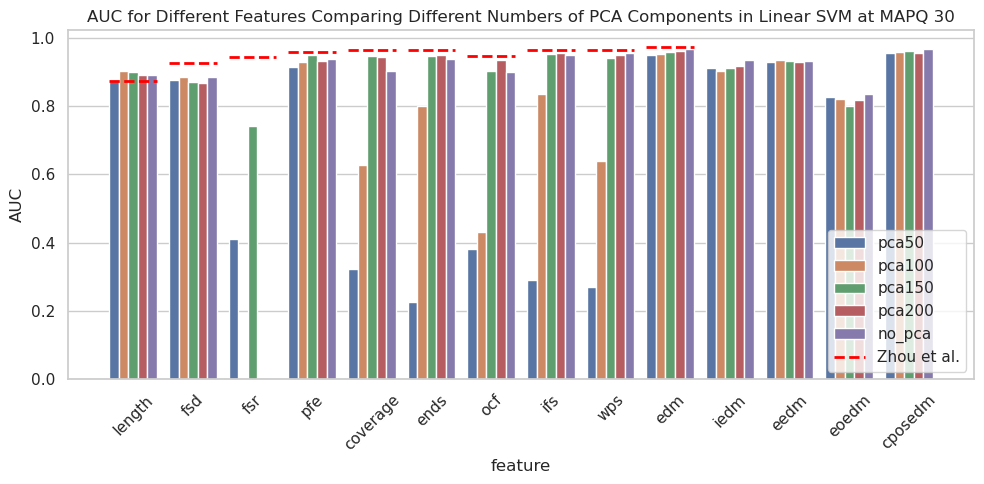

In [22]:
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")
auc_df_melted = auc_df.melt(id_vars='feature', value_vars=['pca50', 'pca100', 'pca150', 'pca200', 'no_pca'], var_name='Model', value_name='AUC')
ax = sns.barplot(data=auc_df_melted, x='feature', y='AUC', hue='Model')
bar_width = 0.8
for i, zhou_val in enumerate(auc_df['zhou']):
    ax.hlines(
        zhou_val,
        i - bar_width / 2,
        i + bar_width / 2,
        colors='red',
        linewidth=2,
        linestyles='--',
        label='Zhou et al.' if i == 0 else ''
    )
plt.xticks(rotation=45)
# plt.ylim(0, 1.0)
plt.title('AUC for Different Features Comparing Different Numbers of PCA Components in Linear SVM at MAPQ 30')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("scripts/analysis/03_pca.png")

## GC Correction

In [23]:
linear_pca150_mapq30 = pd.read_csv(results_folder + "svm_linear_pca150.0_cv1_mapq30_cv_results.csv")
linear_pca150_gc_mapq30 = pd.read_csv(results_folder + "svm_linear_pca150.0_gc_cv1_mapq30_cv_results.csv")
features = pd.DataFrame(['length', 'fsd', 'fsr', 'pfe', 'coverage', 'ends', 'ocf', 'ifs', 'wps', 'edm', 'iedm', 'eedm', 'eoedm', 'cposedm'], columns=['feature'])

auc_df = features.copy()
auc_df = auc_df.merge(linear_pca150_mapq30[['feature', 'auc']].rename(columns={'auc': 'gc_false'}), on='feature', how='left')
auc_df = auc_df.merge(linear_pca150_gc_mapq30[['feature', 'auc']].rename(columns={'auc': 'gc_true'}), on='feature', how='left')
auc_df = auc_df.merge(zhou_scores.reset_index().rename(columns={'auc': 'zhou'}), on='feature', how='left')
auc_df
plt.figure()
auc_tab = auc_df.T


<Figure size 640x480 with 0 Axes>

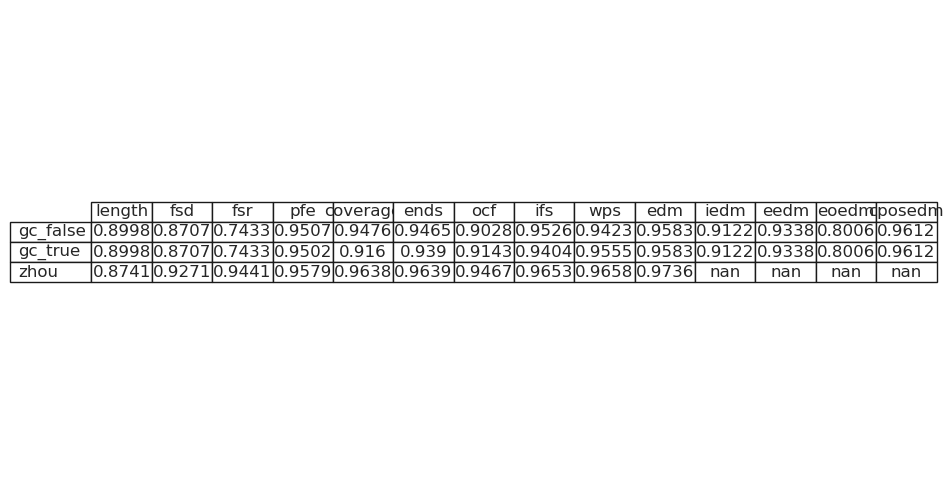

In [24]:
fig, ax = plt.subplots(figsize=(24, 5))
ax.axis('off')
table_data = auc_df[['feature', 'gc_false', 'gc_true', 'zhou']].round(4).T
col_labels = table_data.iloc[0].tolist()  # feature names as column headers
table_data = table_data.iloc[1:]          # drop the feature row
table = ax.table(
    cellText=table_data.values,
    colLabels=col_labels,
    rowLabels=table_data.index.tolist(),
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(2, 1)
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.savefig("scripts/analysis/04_gc_correction_table.png", facecolor='white')
plt.show()


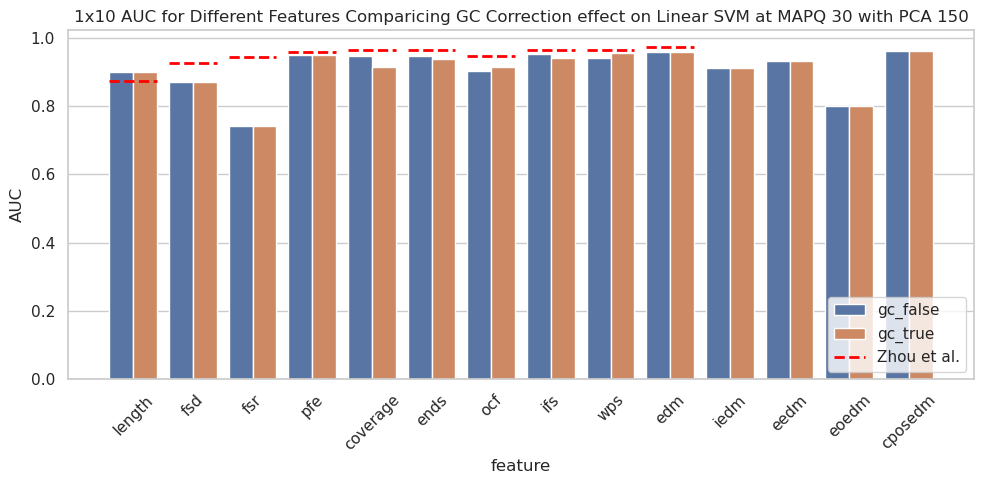

In [25]:
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

auc_df_melted = auc_df.melt(
    id_vars='feature',
    value_vars=['gc_false', 'gc_true'],
    var_name='Model',
    value_name='AUC'
)

ax = sns.barplot(data=auc_df_melted, x='feature', y='AUC', hue='Model')

bar_width = 0.8
for i, zhou_val in enumerate(auc_df['zhou']):
    ax.hlines(
        zhou_val,
        i - bar_width / 2,
        i + bar_width / 2,
        colors='red',
        linewidth=2,
        linestyles='--',
        label='Zhou et al.' if i == 0 else ''
    )

plt.xticks(rotation=45)
# plt.ylim(0.5, 1.0)
plt.title('1x10 AUC for Different Features Comparicing GC Correction effect on Linear SVM at MAPQ 30 with PCA 150')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("scripts/analysis/04_gc_correction.png")

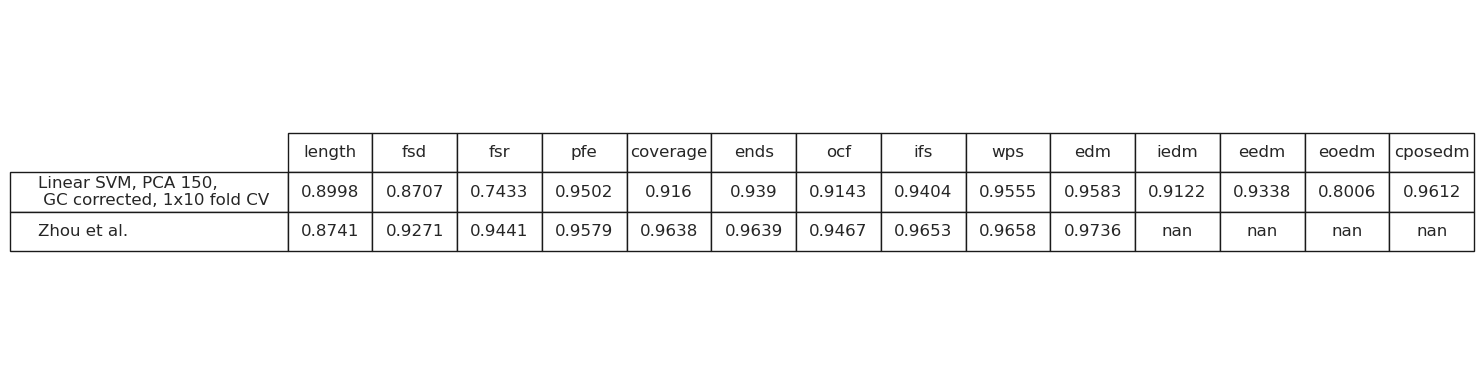

In [26]:
auc_tab = auc_df.set_index('feature')[['gc_true', 'zhou']].round(4).rename(columns={'gc_true': 'Linear SVM, PCA 150,\n GC corrected, 1x10 fold CV', 'zhou': 'Zhou et al.'}).T
fig, ax = plt.subplots(figsize=(15, 4))
ax.axis('off')
table = ax.table(
    cellText=auc_tab.values,
    colLabels=auc_tab.columns,
    rowLabels=auc_tab.index.tolist(),
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 2)
plt.tight_layout()
plt.savefig("scripts/analysis/04_gc_correction_table.png", facecolor='white') 

<Figure size 640x480 with 0 Axes>

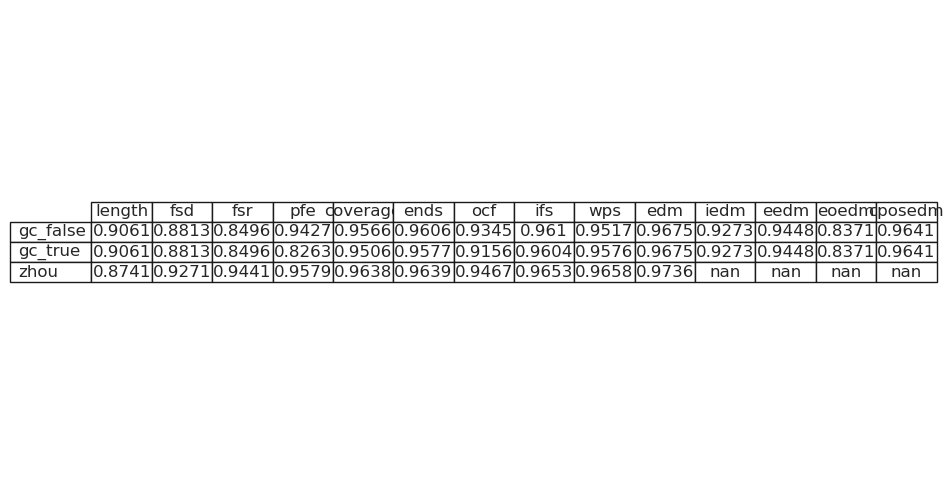

In [27]:
# 10 x 10 cv results for all features, linear kernel, mapq30, pca150, gc correction true vs false
linear_pca150_mapq30 = pd.read_csv(results_folder + "svm_linear_pca150.0_mapq30_cv_results.csv")
linear_pca150_gc_mapq30 = pd.read_csv(results_folder + "svm_linear_pca150.0_gc_mapq30_cv_results.csv")
features = pd.DataFrame(['length', 'fsd', 'fsr', 'pfe', 'coverage', 'ends', 'ocf', 'ifs', 'wps', 'edm', 'iedm', 'eedm', 'eoedm', 'cposedm'], columns=['feature'])

auc_df = features.copy()
auc_df = auc_df.merge(linear_pca150_mapq30[['feature', 'auc']].rename(columns={'auc': 'gc_false'}), on='feature', how='left')
auc_df = auc_df.merge(linear_pca150_gc_mapq30[['feature', 'auc']].rename(columns={'auc': 'gc_true'}), on='feature', how='left')
auc_df = auc_df.merge(zhou_scores.reset_index().rename(columns={'auc': 'zhou'}), on='feature', how='left')
auc_df
plt.figure()
auc_tab = auc_df.T
fig, ax = plt.subplots(figsize=(24, 5))
ax.axis('off')
table_data = auc_df[['feature', 'gc_false', 'gc_true', 'zhou']].round(4).T
col_labels = table_data.iloc[0].tolist()  # feature names as column headers
table_data = table_data.iloc[1:]          # drop the feature row
table = ax.table(
    cellText=table_data.values,
    colLabels=col_labels,
    rowLabels=table_data.index.tolist(),
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(2, 1)
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.savefig("scripts/analysis/05_gc_cv10_table.png", facecolor='white')
plt.show()


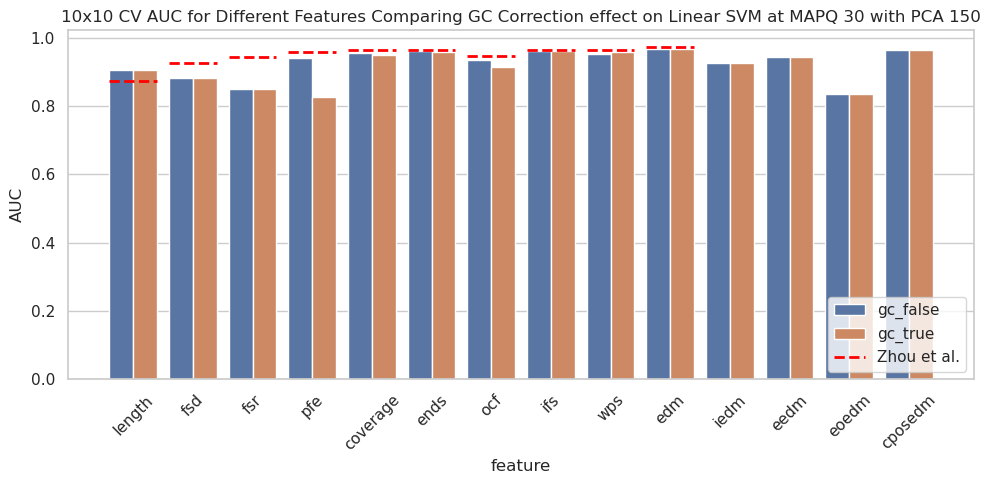

In [28]:
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

auc_df_melted = auc_df.melt(
    id_vars='feature',
    value_vars=['gc_false', 'gc_true'],
    var_name='Model',
    value_name='AUC'
)

ax = sns.barplot(data=auc_df_melted, x='feature', y='AUC', hue='Model')

bar_width = 0.8
for i, zhou_val in enumerate(auc_df['zhou']):
    ax.hlines(
        zhou_val,
        i - bar_width / 2,
        i + bar_width / 2,
        colors='red',
        linewidth=2,
        linestyles='--',
        label='Zhou et al.' if i == 0 else ''
    )

plt.xticks(rotation=45)
# plt.ylim(0.5, 1.0)
plt.title('10x10 CV AUC for Different Features Comparing GC Correction effect on Linear SVM at MAPQ 30 with PCA 150')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("scripts/analysis/05_gc_cv10.png")